<img src="../images/smart_waste_banner.png" width="900">

<h1 style="color: #2E7D32; font-size: 36px; font-weight: bold; text-align: left;">
    Smart Waste Collection Prediction System
</h1>

<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
    Overview
</h2>

Efficient waste collection is an important challenge in growing urban areas. Traditional collection schedules may result in bins being collected before they are full, while other bins may overflow before collection.

This project explores how data science and machine learning can support smarter waste collection by predicting waste-bin fill levels and identifying bins that may require collection.

The project combines data analysis, machine learning, clustering, and geospatial visualization to demonstrate a data-driven approach to waste collection planning.

> **Note:** Geographic coordinates used in the mapping component are synthetically generated within approximate Nairobi boundaries for demonstration purposes and do not represent actual waste-bin locations.


<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
1. Business Understanding
</h2>

### 1.1. Problem Statement

Waste collection operations can become inefficient when collection schedules do not reflect how quickly individual waste bins fill. Some bins may be collected before reaching capacity, while others may overflow before the next scheduled collection.

A data-driven waste management system could help address this problem by estimating bin fill levels and identifying bins that should receive higher collection priority.



### 1.2. Project Objectives

The main objective of this project is to develop a machine learning workflow that predicts waste-bin fill levels and uses the predictions to support waste collection planning.

The project aims to:

1. Explore and clean the available smart-bin data.
2. Identify factors associated with waste-bin fill levels.
3. Develop and evaluate machine learning models for predicting bin fill levels.
4. Use predicted fill levels to identify bins requiring collection priority.
5. Group bins geographically to support collection planning.
6. Visualize collection priorities using an interactive map.

### 1.3. Key Stakeholders

- **County Governments & Municipal Authorites** - Improve waste collection planning, cleanliness, and use of public resources

-  **Waste Collection Companies** - Identify high-priority bins and plan collection activities more efficiently

-  **Waste Collection Teams** - Receive clearer information about which areas or bins require collection

- **Residents & Businesses** -  Benefit from cleaner surroundings and reduced risk of overflowing waste bins


### 1.4. Success Definition

The project will be considered successful if it can:

- Produce a reproducible and well-documented data preparation workflow.
- Develop a predictive model that performs better than a simple baseline.
- Evaluate model performance using appropriate regression metrics such as MAE, RMSE, and R².
- Identify high-priority bins based on predicted fill levels.
- Communicate collection priorities through clear visualizations.

<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
2. Data Understanding
</h2>

Before developing the model, we first need to examine the available datasets to understand their structure, variables, data quality and whether its potentially relevant to the waste collection problem

### 2.1. Import of libraries

In [1]:
# Importing all the necessary libraries for data analysis, visualization, and machine learning

import pandas as pd # data analysis and manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns  # for better enhanced charts
import folium  # creates interactive maps, geospatial data visualization


from sklearn.model_selection import train_test_split  # splits data into training and testing sets
from sklearn.ensemble import RandomForestRegressor # one of the ML algorithms we chose, the building of many decision trees and averaging their results
                                                   # makes it more accurate
from sklearn.cluster import KMeans # used for grouping of waste bins based on geographic location and fill level
from sklearn.preprocessing import StandardScaler, OneHotEncoder # SS standardizes numerical data into a standard scale, helps the model to treat all 
                                                                # features equally, esp units such as kg,% etc
                                                                # OHE converts categorical text data, such as days of the week, into a numerical format 
                                                                # that the model can understand
from sklearn.compose import ColumnTransformer # will allow for scaling different columns, eg, temp, humidity, and categorical columns like the days of 
                                              # the week together in one step b4 training
from sklearn.pipeline import Pipeline # creates a chain/pipeline of all modelling steps that, when we fit and predict, everything else 
                                       # (scaling, encoding, and model training) is done together in one go and automatically
from sklearn.metrics import mean_squared_error, r2_score # measures the model's performance
from sklearn.impute import SimpleImputer

# Random seed for reproducibility, because of the the several random operations in the code, such as splitting the data into training and testing sets, and the random initialization of the KMeans algorithm
RANDOM_STATE = 42

pd.set_option('display.max_columns', None)  # display all columns in the dataframe

### 2.2. Loading the datasets
We have two datasets available;
1. **Smart Bin Dataset** - has observations & characteristics associated with smart waste and will serve as the primary dataset for the predictive modelling
2. **Kenya Waste Management Dataset** - provides broader contextual info about waste management in major Kenyan towns

I will first examine the smart-bin dataset because it forms the basis of the machine learning component

In [2]:
# Load the datasets

bins = pd.read_csv('../datasets/raw/Smart_Bin.csv')
print("SMART BIN DATASET(KAGGLE)")
display(bins.head())

#Open Data
kenya = pd.read_csv('../datasets/raw/waste-management-status-in-major-towns-of-kenya.csv')
print("\nKENYA WASTE MGT DATASET(OPENDATA)")
display(kenya.head())

SMART BIN DATASET(KAGGLE)


,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction
0,Emptying,85.3,34.4,6.0,75.9,54.7,83.3,39.8,Silvertop-a,Mixed
1,Emptying,96.2,51.7,8.0,83.3,33.9,85.0,57.4,BIM-3 FTI bottentomd,Non Recyclable
2,Non Emptying,50.9,63.5,5.0,30.8,55.7,51.7,68.5,BIM-3 FTI bottentomd,Recyclable
3,Emptying,83.1,33.9,6.0,91.8,61.1,84.6,43.6,Lindstrom-a,Mixed
4,Non Emptying,73.5,32.2,3.0,68.0,30.5,62.4,53.0,Lindstrom-a,Non Recyclable



KENYA WASTE MGT DATASET(OPENDATA)


,Unnamed: 0,Estimated Waste generated (tons/day),Waste collected,Waste Recovery,Uncollected waste
0,Nairobi,2400,80,45,20
1,Nakuru,250,45,18,37
2,Kisumu,400,20,Unknown,Unknown
3,Thika,140,60,30,40
4,Mombasa,2200,65,40,35


In [3]:
bins.head()

,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction
0,Emptying,85.3,34.4,6.0,75.9,54.7,83.3,39.8,Silvertop-a,Mixed
1,Emptying,96.2,51.7,8.0,83.3,33.9,85.0,57.4,BIM-3 FTI bottentomd,Non Recyclable
2,Non Emptying,50.9,63.5,5.0,30.8,55.7,51.7,68.5,BIM-3 FTI bottentomd,Recyclable
3,Emptying,83.1,33.9,6.0,91.8,61.1,84.6,43.6,Lindstrom-a,Mixed
4,Non Emptying,73.5,32.2,3.0,68.0,30.5,62.4,53.0,Lindstrom-a,Non Recyclable


In [4]:
bins.tail()

,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction
4633,Emptying,51.9,32.0,4.0,59.3,30.8,53.6,33.2,Silvertop-a,Mixed
4634,Non Emptying,62.7,22.7,8.0,68.1,35.5,68.9,31.4,Rectangular,Recyclable
4635,Emptying,53.9,30.2,4.0,52.5,32.5,53.7,34.7,Cubic,Mixed
4636,Non Emptying,84.8,41.2,7.0,81.4,50.4,83.0,40.6,Rectangular,Recyclable
4637,Emptying,61.1,52.0,3.0,61.0,58.4,61.2,57.9,Diamond,Mixed


In [5]:
kenya.head()

,Unnamed: 0,Estimated Waste generated (tons/day),Waste collected,Waste Recovery,Uncollected waste
0,Nairobi,2400,80,45,20
1,Nakuru,250,45,18,37
2,Kisumu,400,20,Unknown,Unknown
3,Thika,140,60,30,40
4,Mombasa,2200,65,40,35


In [6]:
kenya.tail()

,Unnamed: 0,Estimated Waste generated (tons/day),Waste collected,Waste Recovery,Uncollected waste
1,Nakuru,250,45,18,37
2,Kisumu,400,20,Unknown,Unknown
3,Thika,140,60,30,40
4,Mombasa,2200,65,40,35
5,Eldoret,600,55,15,45


#### 2.2.1. Inspection of dataset

In [7]:
# Inspect the smart bin dataset, its data structure
# The examination includes the dimensions, column names,data types, and summary statistics of the dataset.
#  This step is crucial for understanding the data and identifying any potential issues that may need to be addressed before further analysis or modeling.

print(f"Number of rows: {bins.shape[0]:,} and Number of columns: {bins.shape[1]:,}")
bins.info()  # provides a concise summary of the DataFrame, including the number of non-null entries and data types for each column

Number of rows: 4,638 and Number of columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Class                4638 non-null   object 
 1   FL_B                 4636 non-null   float64
 2   FL_A                 4638 non-null   float64
 3   VS                   4631 non-null   float64
 4   FL_B_3               4638 non-null   float64
 5   FL_A_3               4634 non-null   float64
 6   FL_B_12              4633 non-null   float64
 7   FL_A_12              4638 non-null   float64
 8   Container Type       4638 non-null   object 
 9   Recyclable fraction  4638 non-null   object 
dtypes: float64(7), object(3)
memory usage: 362.5+ KB


In [8]:
bins.columns.tolist()
bins.describe(include='all'). T # provides summary statistics for each column, including count, mean, std, min, max, and percentiles for numerical columns, and count, unique, top, and freq for categorical columns

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Class,4638,2,Non Emptying,2364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FL_B,4636.0,NaN,NaN,NaN,68.619737,18.094653,15.3,58.4,69.4,81.7,198.3
FL_A,4638.0,NaN,NaN,NaN,45.419685,14.880283,13.8,32.9,46.3,56.4,99.5
VS,4631.0,NaN,NaN,NaN,5.116605,2.448212,1.0,3.0,6.0,7.0,9.0
FL_B_3,4638.0,NaN,NaN,NaN,68.389845,18.111428,17.4,58.9,69.3,81.7,154.6
FL_A_3,4634.0,NaN,NaN,NaN,45.327902,14.930041,19.3,32.9,45.85,56.6,99.8
FL_B_12,4633.0,NaN,NaN,NaN,68.701964,18.192151,16.3,58.4,69.3,82.0,217.4
FL_A_12,4638.0,NaN,NaN,NaN,45.483161,14.759144,16.9,32.9,47.2,56.5,96.1
Container Type,4638,14,Lindstrom-a,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recyclable fraction,4638,3,Non Recyclable,1578,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2.2. Variable exploration
Before selecting the target variable & predictors, I needed to examine the variables individually to understand their values and potential roles in the analysis

I specifically checked the 'class' variable since it contains 2 categories and may represent the waste collection outcome that the model should predict

In [9]:
# This code is doing categorical data exploration. 
# It lets us see exactly what categories exist in the three non-numeric columns and how frequently each category occurs.
for column in ["Class", "Container Type", "Recyclable fraction"]: # python will examine these 3 columns in a loop, one after the other
    print(f"\n{column} value counts:")
    print(bins[column].value_counts(dropna=False))  # value_counts() counts the occurrences of each unique value in the column, including NaN values (dropna=False)


Class value counts:
Class
Non Emptying    2364
Emptying        2274
Name: count, dtype: int64

Container Type value counts:
Container Type
Lindstrom-a             371
Lindstrom City          362
Cubic                   357
Fiberglass Igloo-a      354
Accordion               332
Rectangular             332
Silvertop-b             328
Rectangular Farmland    320
Malmobehallare          319
Diamond                 318
Silvertop-a             317
Fiberglass Igloo-b      315
Lindstrom-b             311
BIM-3 FTI bottentomd    302
Name: count, dtype: int64

Recyclable fraction value counts:
Recyclable fraction
Non Recyclable    1578
Recyclable        1533
Mixed             1527
Name: count, dtype: int64


In [10]:
# Fill-level variables inspection
fill_columns = [
    "FL_A",
    "FL_B",
    "FL_A_3",
    "FL_B_3",
    "FL_A_12",
    "FL_B_12"
]

bins[fill_columns].describe()  # provides summary statistics for the fill-level columns, including count, mean, std, min, max, and percentiles

,FL_A,FL_B,FL_A_3,FL_B_3,FL_A_12,FL_B_12
count,4638.000000,4636.000000,4634.000000,4638.000000,4638.000000,4633.000000
mean,45.419685,68.619737,45.327902,68.389845,45.483161,68.701964
std,14.880283,18.094653,14.930041,18.111428,14.759144,18.192151
min,13.800000,15.300000,19.300000,17.400000,16.900000,16.300000
25%,32.900000,58.400000,32.900000,58.900000,32.900000,58.400000
50%,46.300000,69.400000,45.850000,69.300000,47.200000,69.300000
75%,56.400000,81.700000,56.600000,81.700000,56.500000,82.000000
max,99.500000,198.300000,99.800000,154.600000,96.100000,217.400000


In [11]:
bins.groupby("Class")[fill_columns + ["VS"]].mean().round(2)

,FL_A,FL_B,FL_A_3,FL_B_3,FL_A_12,FL_B_12,VS
Class,,,,,,,
Emptying,45.41,78.70,45.80,73.67,45.67,74.03,6.81
Non Emptying,45.43,58.92,44.87,63.31,45.30,63.58,3.49


#### 2.2.3. Missing values inspection

In [12]:
# missing values inspection
missing_values = (
    bins.isnull().sum()  # counts the number of missing values in each column
    .sort_values(ascending=False)  # sorts the columns by the number of missing values in descending order
)

missing_values_percentage = (missing_values / bins.shape[0]) * 100  # calculates the percentage of missing values in each column

print("\nMissing Values Count:")
print(missing_values)

print("\nMissing Values Percentage:")
print(missing_values_percentage)


Missing Values Count:
VS                     7
FL_B_12                5
FL_A_3                 4
FL_B                   2
Class                  0
FL_A                   0
FL_B_3                 0
FL_A_12                0
Container Type         0
Recyclable fraction    0
dtype: int64

Missing Values Percentage:
VS                     0.150927
FL_B_12                0.107805
FL_A_3                 0.086244
FL_B                   0.043122
Class                  0.000000
FL_A                   0.000000
FL_B_3                 0.000000
FL_A_12                0.000000
Container Type         0.000000
Recyclable fraction    0.000000
dtype: float64


#### 2.2.4. Duplicate values
Inspected for duplicates to determine whether the dataset has repeated records that could affect analysis and model training

In [13]:
duplicate_count = bins.duplicated().sum()  # counts the number of duplicate rows in the dataset
print(f"\nNumber of duplicate rows: {duplicate_count}") 

duplicate_percentage = (duplicate_count / bins.shape[0]) * 100  # calculates the percentage of duplicate rows in the dataset
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")


Number of duplicate rows: 304
Percentage of duplicate rows: 6.55%


#### 2.2.5. Investigation of Class
This is to determine whether 'Class' can actually be used as our prediction target

In [14]:
# Since we already have the value counts we can check the distribution
bins["Class"].value_counts(normalize=True).mul(100).round(2)

Class
Non Emptying    50.97
Emptying        49.03
Name: proportion, dtype: float64

In [15]:
# Compare numeric measurements across classes
numeric_columns = [
    "FL_A",
    "FL_B",
    "FL_A_3",
    "FL_B_3",
    "FL_A_12",
    "FL_B_12",
    "VS"
]

class_summary = (
    bins.groupby("Class")[numeric_columns]
    .mean()
    .round(2)
)

class_summary

,FL_A,FL_B,FL_A_3,FL_B_3,FL_A_12,FL_B_12,VS
Class,,,,,,,
Emptying,45.41,78.70,45.80,73.67,45.67,74.03,6.81
Non Emptying,45.43,58.92,44.87,63.31,45.30,63.58,3.49


#### 2.6. Data Inspection Findings

The initial inspection revealed the following about the dataset;

The dataset contains **4,638 observations and 10 variables**, consisting of both numerical and categorical features.
- The target variable, `Class`, contains two categories: **Emptying** and **Non Emptying**. The classes are nearly balanced, with approximately **49% Emptying and 51% Non Emptying**, which is suitable for a binary classification problem.
- Only a small number of missing values were identified in the numerical variables. Since the proportion of missing data is very low, these values can be handled through imputation during preprocessing rather than removing large portions of the dataset.
- The dataset contains **304 duplicate rows (6.55%)**, which should be removed before modelling to avoid repeated observations influencing model training.
- Preliminary comparison of the numerical variables across the two classes shows noticeable differences in variables such as `FL_B`, `FL_B_3`, `FL_B_12`, and `VS`, suggesting that these variables may contain useful information for distinguishing between Emptying and Non Emptying observations.
- In contrast, the mean values of `FL_A`, `FL_A_3`, and `FL_A_12` appear relatively similar between the two classes. Further exploratory analysis will be conducted to understand their predictive value.
- Based on these findings, `Class` will be used as the target variable, changing the problem from the original fill-level regression approach to a **binary classification problem**.


<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
3. Data Preparation
</h2>

The data preparation stage focusses on creating a clean and reproducible dataset for machine learning

Based on initial inspection, the 'Class' variable was selected as the target for a binary classification problem and the remaining variables as potential predictors

This process of preparation includes;
- Removing the duplicate observations
- Separating the target variables from the predictor variables
- Identifying the numeriacal and categorical features
- Handling the missing values through preprocessing
- Preparing the data for ML without bring up any data leakage

#### 3.1. Duplicate removal

Exact duplicate observations were removed before model deployment, this helps in reducing the possibility of repeated observations across the training and testing datasets, which enhances the model performance

In [16]:
bins_clean = bins.drop_duplicates().copy()  # creates a new DataFrame without duplicate rows, ensuring that the original DataFrame remains unchanged
print(f"Rows before removing duplicates: {len(bins):,}")
print(f"Rows after removing duplicates: {len(bins_clean):,}")
print(f"Rows removed: {len(bins) - len(bins_clean):,}")

Rows before removing duplicates: 4,638
Rows after removing duplicates: 4,334
Rows removed: 304


#### 3.2. Target and predictor variables definition

In [17]:
# Definition of target and predictor variables
X = bins_clean.drop(columns= "Class")  # predictor variables, all columns except the target variable "Class"
y = bins_clean["Class"]  # target variable, the "Class" column which we want to predict

print(f"Predictor variables shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Predictor variables shape: (4334, 9)
Target variable shape: (4334,)


#### 3.3. Identifying the feature types

In [18]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()  # selects all numeric columns from the predictor variables and converts them to a list
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()  # selects all categorical columns from the predictor variables and converts them to a list

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12']
Categorical features: ['Container Type', 'Recyclable fraction']


#### 3.4. Missing Values

For the small number of missing values identified in the numerical variables during the inspection stage, rather than remooving these observatiobs or filling the values before splitting the dataset, missing values will be handled within the machine learning preprocessing pipeline.

Median imputation will be used for numerical features, so this step will be worked on in the preprocessing pipeline to prevent info from the test set from influencing the model during training

<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
4. Exploratory Data Analysis (EDA)
</h2>

EDA is used to examine patterns, distributions and relationships within the prepared Smart Bin dataset

This analysis will focus on understanding how sensor measurements & bin characteristics relate to the target variable, 'Class'

Our EDA will examine;
- The distribution of the target classes
- The distributions of numerical sensor measurements
- Differences in numerical measurements between the target classes
- Relationships between categorical features and emptying status 
- Correlations between numerical features

#### 4.1. Target Class Distribution

Class
Non Emptying    2210
Emptying        2124
Name: count, dtype: int64

Class distribution percentage:
Class
Non Emptying    50.99
Emptying        49.01
Name: proportion, dtype: float64


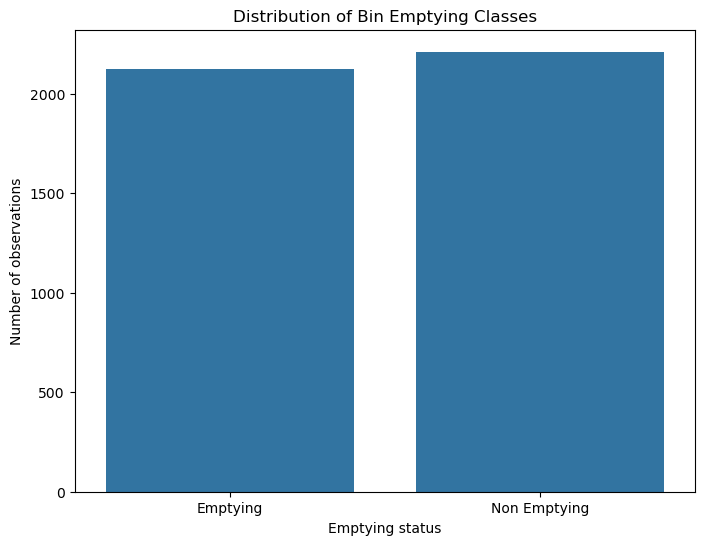

In [19]:
# Target class distribution examination
class_counts = bins_clean["Class"].value_counts()
class_counts_percentage = bins_clean["Class"].value_counts(normalize=True) * 100

print(class_counts)
print("\nClass distribution percentage:")
print(class_counts_percentage.round(2))

# Class distribution visualization
plt.figure(figsize=(8, 6))

sns.countplot(
    data = bins_clean,
    x = "Class",
)

plt.title("Distribution of Bin Emptying Classes")
plt.xlabel("Emptying status")
plt.ylabel("Number of observations")
plt.show()

##### Observation
The target variable is approximately balanced between the 'Emptying' & 'Non Emptying" classes

Its useful for classification because neither class is largely underrepresented. Therefore, severe class imbalance is unlikely to be a major concern during model development

However, model performance will still be evaluated using multiple classification metrics rather than accuracy alone

#### 4.2. Numerical Feature Distributions

In [20]:
# We sepparate the numeric and categorical features for further analysis and preprocessing. 
# This separation is crucial because different types of features often require different preprocessing techniques before they can be used in machine learning models.
# X is the info we'll use to make predictions, and y is the target variable we want to predict.

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12']

Categorical features:
['Container Type', 'Recyclable fraction']


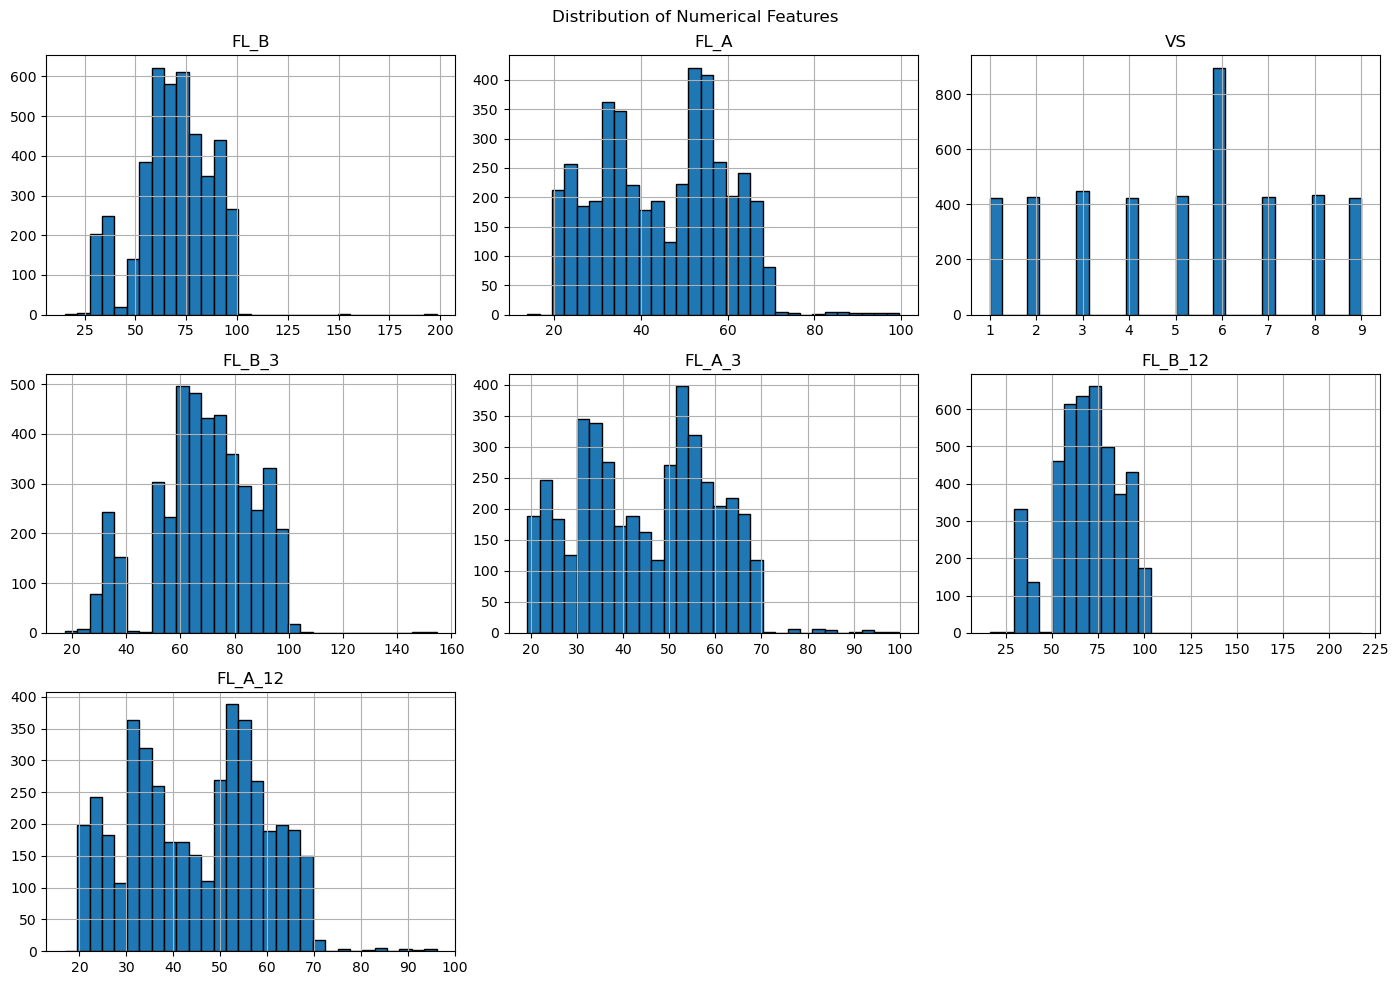

In [21]:
# Numerical feature distribution visualization
bins_clean[numeric_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

##### Observation

The numerical features show 7 different distribution patterns

- The fill levels('FL_A', 'FL_A_3' and 'FL_A_12') variables have broadly similar, distributions, with observations indicating multiple areas where lots are concentrated

- The `FL_B`, `FL_B_3`, and `FL_B_12` variables also show similar distributions, with most observations concentrated within the middle ranges and a small number of unusually high values.

- `VS` behaves differently from the other numerical features because it takes discrete values between 1 and 9, with a noticeably higher concentration at 6.

- Potential extreme values are visible in some of the `FL` variables. These observations should be investigated further rather than automatically removed.

- The similarity between related `FL_A` and `FL_B` variables suggests that some numerical features may contain overlapping information. This will be investigated further using correlation analysis.

Overall, the numerical variables do not appear to follow simple normal distributions, highlighting the importance of further investigating their relationships with the target variable before model development.

#### 4.3. Numerical features vs Emptying status

To investigate which numerical features may be associated with bin emptying status, we have to use the distribution of the sensor measurements compared to 'Emptying' and 'Non emptying' classes

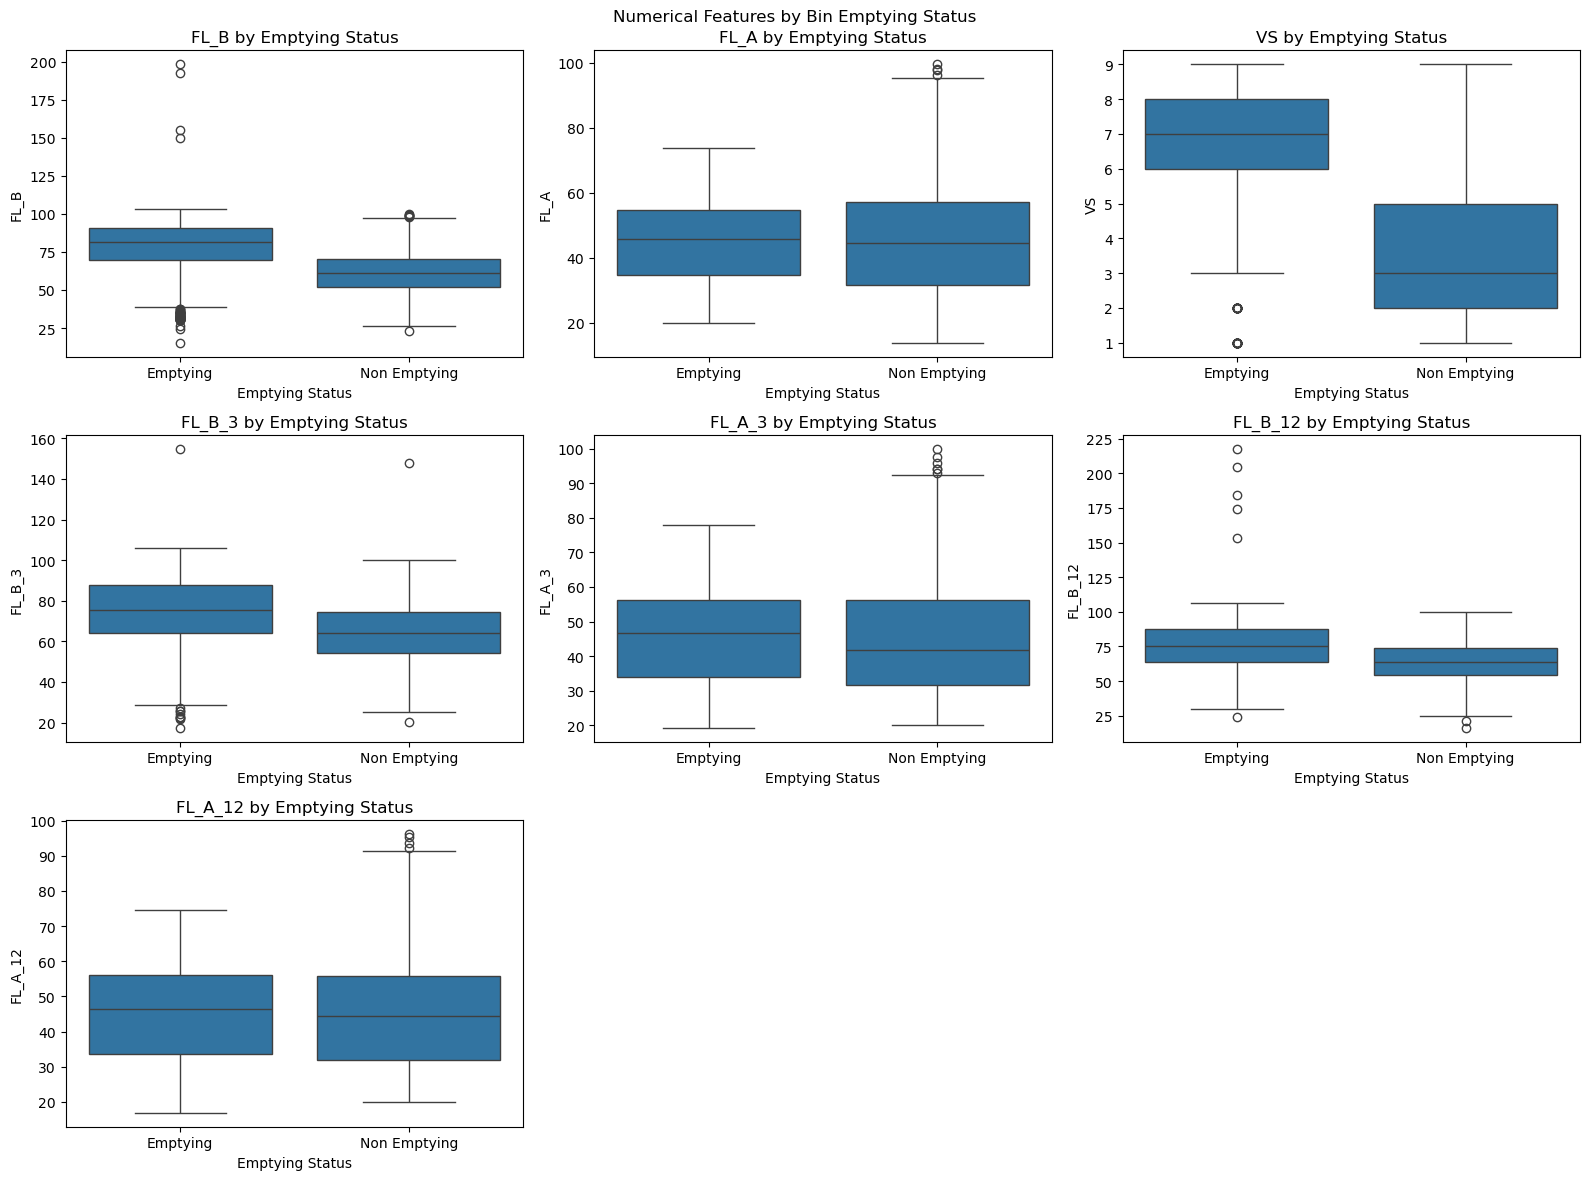

In [22]:
#  Compare numerical features by emptying status
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=bins_clean,
        x="Class",
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} by Emptying Status")
    axes[i].set_xlabel("Emptying Status")
    axes[i].set_ylabel(feature)

# Remove unused subplot spaces
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
    

plt.suptitle("Numerical Features by Bin Emptying Status")
plt.tight_layout()
plt.show()

##### Observations

The comparison of numerical features across the target classes reveals noticeable differences in several sensor measurements.

- `FL_B`, `FL_B_3`, and `FL_B_12` generally have higher values for `Emptying` observations than for `Non Emptying` observations, suggesting that these variables may contain useful information for predicting emptying status.

- `VS` also shows clear separation between the two classes, with `Emptying` observations generally having higher values.

- In contrast, `FL_A`, `FL_A_3`, and `FL_A_12` show greater overlap between the two classes, suggesting weaker individual separation based on these features.

- Potential outliers are present in some of the numerical variables. These observations will not be removed automatically because they may represent valid sensor measurements.

Overall, `FL_B`, its related measurements, and `VS` appear to be particularly relevant candidates for predicting bin emptying status. Their predictive usefulness will be evaluated during model development.

#### 4.4. Correlation Analysis
The main question we ask here is;

**Are some of the numerical variables strongly related to each other**

This is a very relevant question because of what the histogram suggests

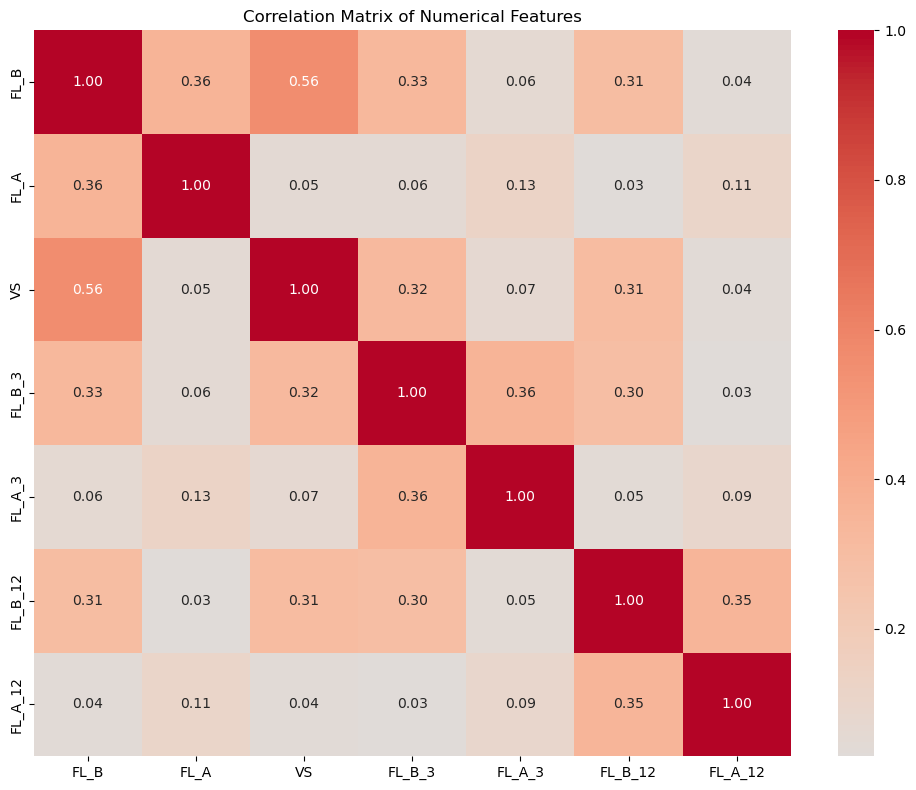

In [23]:
# Calculation of correlation matrix for numerical features
correlation_matrix = bins_clean[numeric_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

##### Observations

This correlation matrix shows that most numerical features have weak to moderate linear relationship with one another

- The strongest observed relationship is between 'FL_B' & 'VS' with a correlation of around **0.56**, this indicates a moderate positive relationship
- `FL_B` has weaker positive relationships with `FL_A` (0.36), `FL_B_3` (0.33), and `FL_B_12` (0.31).
- Most other feature pairs have relatively low correlations.
- Despite similarities observed in some of the feature distributions, the correlation results suggest that the numerical variables are not simply providing identical information.

Overall, there is no evidence of extremely high correlation among the numerical predictors, reducing immediate concerns about severe multicollinearity. The usefulness of individual features will be investigated further during model development.


#### 4.5. Categorical features vs Emptying status

Now that we are done with the numerical EDA, we will investigate 2 categorical variables 'Container Type' & 'Recyclable fraction'

So, the main question is **Does emptying status vary depending on container type or recyclable fraction?

In [ ]:
# Recyclable fraction

# Because there are several container types, calculating percentages is more informative
# than using raw counts. This allows us to compare emptying status across container types
# even when the number of observations in each category differs.

recyclable_class_percentage = pd.crosstab(
    bins_clean["Recyclable fraction"],
    bins_clean["Class"],
    normalize="index"
) * 100  # convert to percentage

recyclable_class_percentage.round(2)

Class,Emptying,Non Emptying
Recyclable fraction,,
Mixed,50.32,49.68
Non Recyclable,47.81,52.19
Recyclable,48.96,51.04


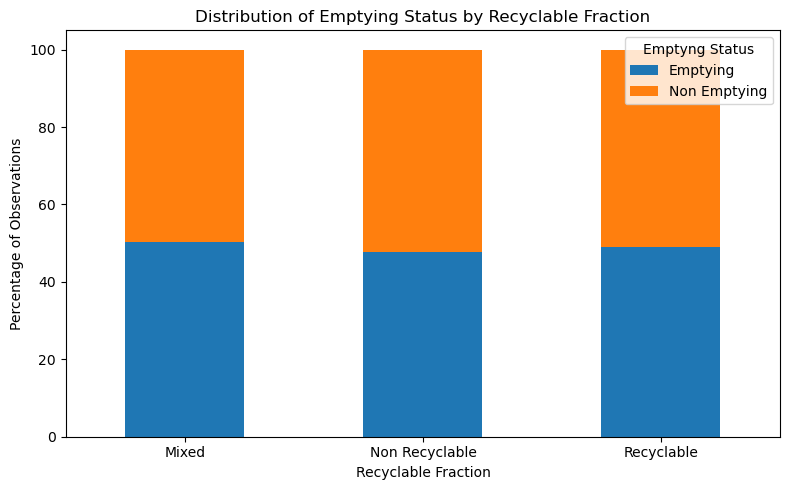

In [ ]:
# Recyclable fraction distribution visualization
recyclable_class_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Distribution of Emptying Status by Recyclable Fraction")
plt.xlabel("Recyclable Fraction")
plt.ylabel("Percentage of Observations")
plt.xticks(rotation=0)
plt.legend(title="Emptyng Status")
plt.tight_layout()
plt.show()

##### Observations

Emptying status is distributed relatively evenly across the 3 recyclable fraction categories;

- 'Mixed' is appreoximately evenly distributed between 'Emptying' (50.32%) & 'Non Emptying' (49.68%)
- `Non Recyclable` show a slightly higher proportion of `Non Emptying` cases (52.19%)
- `Recyclable` observations are also relatively balanced, with 48.96% classified as `Emptying` and 51.04% as `Non Emptying`

Overall, the differences between the recyclable-fraction categories are small. This suggests that `Recyclable fraction` may have limited ability on its own to distinguish between `Emptying` and `Non Emptying` observations. Its usefulness will still be evaluated alongside the other features during modelling.

In [29]:
# Container Type

container_class_percentage = pd.crosstab(
    bins_clean["Container Type"],
    bins_clean["Class"],
    normalize="index"
) * 100  # convert to percentage

container_class_percentage.round(2)

Class,Emptying,Non Emptying
Container Type,,
Accordion,49.19,50.81
BIM-3 FTI bottentomd,42.20,57.80
Cubic,50.47,49.53
Diamond,47.70,52.30
Fiberglass Igloo-a,53.66,46.34
Fiberglass Igloo-b,52.38,47.62
Lindstrom City,47.51,52.49
Lindstrom-a,48.99,51.01
Lindstrom-b,46.69,53.31


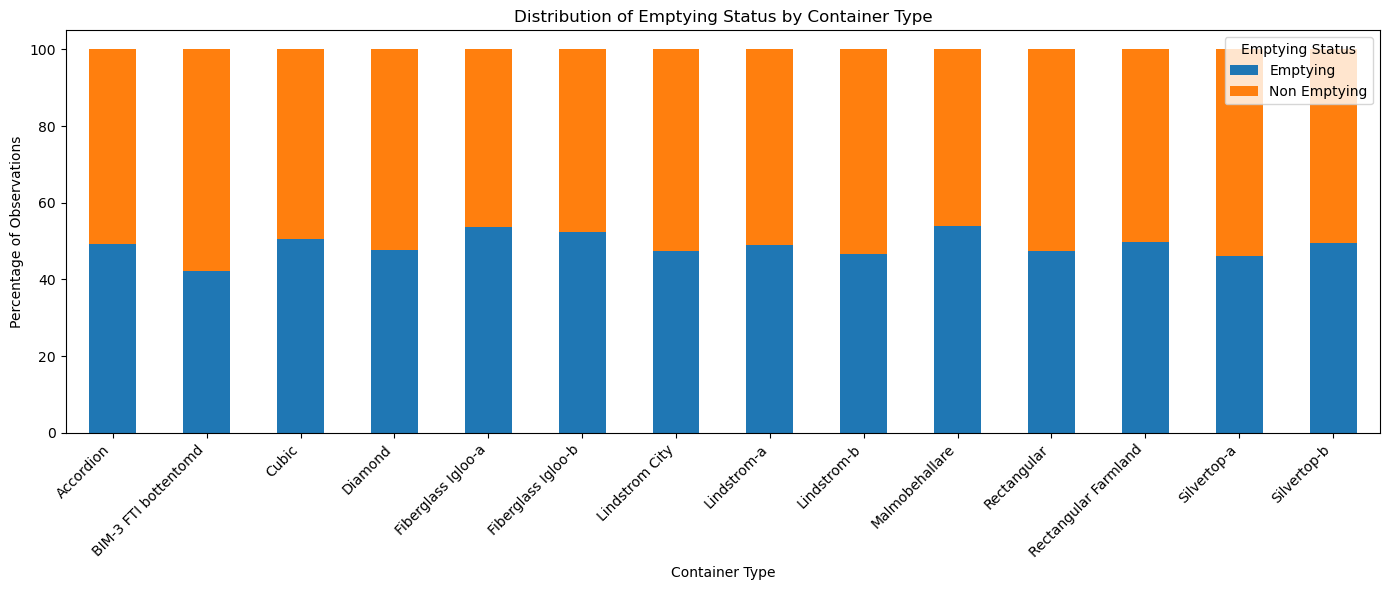

In [30]:
# Container type distribution visualization
container_class_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Distribution of Emptying Status by Container Type")
plt.xlabel("Container Type")
plt.ylabel("Percentage of Observations")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Emptying Status")
plt.tight_layout()
plt.show()

##### Observations

Emptying status varies somewhat across container types, although most categories remain relatively close to an even split between `Emptying` and `Non Emptying`.

- Some container types show slightly higher proportions of `Emptying` observations, while others show somewhat higher proportions of `Non Emptying`.
- However, the differences between container types are relatively modest compared with the separation observed for numerical features such as `FL_B` and `VS`.
- This suggests that `Container Type` may provide some additional information but is unlikely to distinguish emptying status strongly on its own.

Together with the recyclable-fraction analysis, the categorical features appear to provide less obvious separation between the target classes than some of the numerical sensor measurements. Their contribution will still be evaluated during ML modelling.

#### 4.6. EDA Summary

The exploratory analysis identified several patterns relevant to the prediction problem:

- The target variable is approximately balanced between `Emptying` and `Non Emptying`.
- Several numerical variables contain potential extreme values, which will be retained unless there is sufficient evidence that they represent data errors.
- `FL_B`, `FL_B_3`, `FL_B_12`, and `VS` show noticeable differences between the two target classes and may provide useful predictive information.
- The `FL_A` variables show greater overlap between the target classes.
- No extremely high correlations were identified among the numerical predictors, suggesting that severe multicollinearity is not an immediate concern.
- `Container Type` and `Recyclable fraction` show relatively small differences in emptying proportions and appear less informative individually than some of the numerical sensor measurements.

These findings provide the basis for developing and comparing classification models in the next stage.

<h2 style="color: #F9A825; font-size: 28px; font-weight: bold; text-align: left;">
5. Predictive Modelling
</h2>

# PART 3: Cleaning the data and feature preparation

In [24]:
print(bins.columns.tolist())

# so currently we have fill-level data spread out accross multiple columns
# Combine multiple fill-level columns into one average column as the model expects
fill_cols = ['FL_A', 'FL_B', 'FL_A_3', 'FL_B_3', 'FL_A_12', 'FL_B_12']

# Check if they all exist in your dataset before using
fill_cols = [col for col in fill_cols if col in bins.columns]

# Create the unified fill_level column
bins['fill_level'] = bins[fill_cols].mean(axis=1)

# Preview new column
print(bins[['fill_level']].head())


['Class', 'FL_B', 'FL_A', 'VS', 'FL_B_3', 'FL_A_3', 'FL_B_12', 'FL_A_12', 'Container Type', 'Recyclable fraction']
   fill_level
0   62.233333
1   67.916667
2   53.516667
3   66.350000
4   53.266667


In [25]:
# we first check for duplicates and missing values in the datasets
print("Duplicate rows are:", bins.duplicated().sum())
print("\nMissing values per column are:\n", bins.isnull().sum())

# drop these rows
bins= bins.drop_duplicates()
bins.dropna(subset=['fill_level'], inplace=True)


# so a timestamp is important in making the model to predict fill levels more accurately, since waste generation varies by the time of day
#and day of the week, so we check for a timestamp and if there isnt one we create it

# Convert timestamp (if present) to datetime for time-based features
if 'timestamp' in bins.columns:
    bins['timestamp'] = pd.to_datetime(bins['timestamp'])
    bins['hour'] = bins['timestamp'].dt.hour
    bins['day'] = bins['timestamp'].dt.day_name()
else:
    # If timestamp doesn't exist, create simulated time features
    bins['hour'] = np.random.randint(0, 24, len(bins))
    bins['day'] = np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], len(bins))

# View summary after cleaning
print("\nCleaned Dataset Sample:")
display(bins.head())


Duplicate rows are: 304

Missing values per column are:
 Class                  0
FL_B                   2
FL_A                   0
VS                     7
FL_B_3                 0
FL_A_3                 4
FL_B_12                5
FL_A_12                0
Container Type         0
Recyclable fraction    0
fill_level             0
dtype: int64

Cleaned Dataset Sample:


,Class,FL_B,FL_A,VS,FL_B_3,FL_A_3,FL_B_12,FL_A_12,Container Type,Recyclable fraction,fill_level,hour,day
0,Emptying,85.3,34.4,6.0,75.9,54.7,83.3,39.8,Silvertop-a,Mixed,62.233333,17,Sat
1,Emptying,96.2,51.7,8.0,83.3,33.9,85.0,57.4,BIM-3 FTI bottentomd,Non Recyclable,67.916667,12,Sat
2,Non Emptying,50.9,63.5,5.0,30.8,55.7,51.7,68.5,BIM-3 FTI bottentomd,Recyclable,53.516667,12,Thu
3,Emptying,83.1,33.9,6.0,91.8,61.1,84.6,43.6,Lindstrom-a,Mixed,66.350000,21,Sat
4,Non Emptying,73.5,32.2,3.0,68.0,30.5,62.4,53.0,Lindstrom-a,Non Recyclable,53.266667,16,Thu


# PART 4: Feature selection and model training

In [26]:
# ==============================================================
# STEP: Train Random Forest Model for Bin Fill Level Prediction
# ==============================================================

# 1️⃣ Choose features based on data types
numeric_features = ['FL_A', 'FL_B', 'VS']  # purely numeric sensor readings
categorical_features = ['Container Type', 'Class', 'Recyclable fraction']  # text columns

target = 'fill_level'
features = numeric_features + categorical_features

# 2️⃣ Split dataset into features (X) and target (y)
X = bins[features]
y = bins[target]

# 3️⃣ Preprocessing pipeline with imputation for missing values
preprocessor = ColumnTransformer([
    # Add SimpleImputer to handle missing values in numeric features
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean
        ('scaler', StandardScaler())
    ]), numeric_features),
    
    # Add SimpleImputer with 'most_frequent' strategy for categorical features
    ('category', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Replace NaN with most frequent value
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

# 4️⃣ Split data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Build the Random Forest model pipeline
RFM = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train the model
RFM.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("Model Evaluation:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

NameError: name 'model' is not defined

# Visualizing the predictions

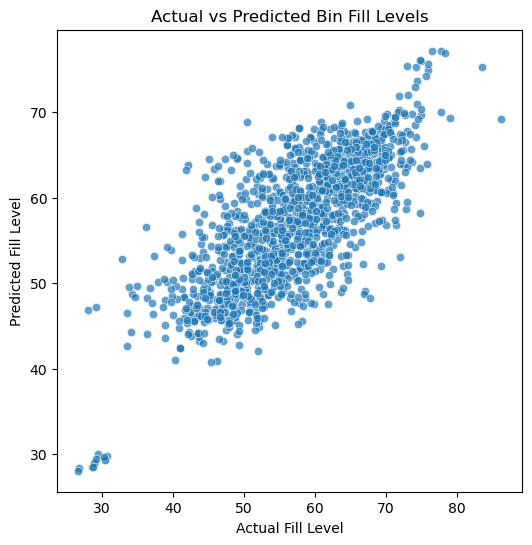

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel('Actual Fill Level')
plt.ylabel('Predicted Fill Level')
plt.title('Actual vs Predicted Bin Fill Levels')
plt.show()


# PART 5: Route Optimization (KMeans)

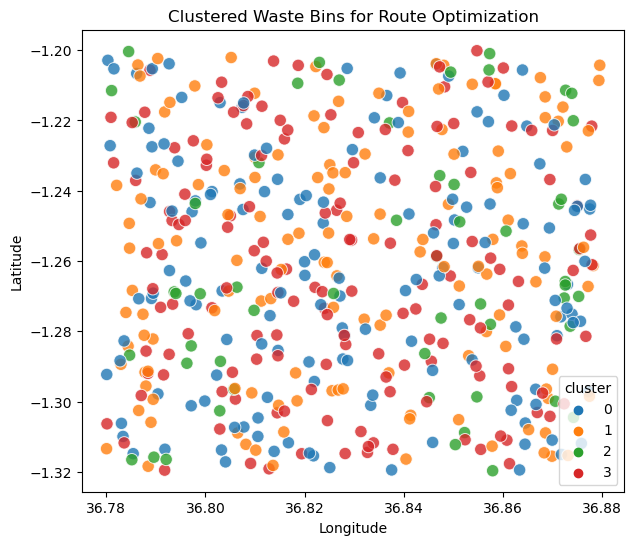

In [ ]:
# Ensured we have location data; if not, simulate approximate Nairobi coordinates
if 'latitude' not in bins.columns or 'longitude' not in bins.columns:
    bins['latitude'] = np.random.uniform(-1.320, -1.200, len(bins))
    bins['longitude'] = np.random.uniform(36.780, 36.880, len(bins))

# Use predicted fill levels for more realistic clustering
bins['predicted_fill'] = model.predict(X)

# Select relevant features for clustering
cluster_data = bins[['latitude', 'longitude', 'predicted_fill']]

# Apply K-Means (4 clusters for example)
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
bins['cluster'] = kmeans.fit_predict(cluster_data)

# Visualize clusters
plt.figure(figsize=(7,6))
sns.scatterplot(data=bins.sample(500), x='longitude', y='latitude', hue='cluster', palette='tab10', s=80, alpha=0.8)
plt.title('Clustered Waste Bins for Route Optimization')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
# creation of an interactive map

import folium

# create the map centered on Nairobi
nairobi_map = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# define colors for different zones
zone_colors = {
    'CBD': 'red',
    'Westlands': 'blue',
    'Eastlands': 'green',
    'South B / Industrial Area': 'orange'
}

# plot bins by zone
for _, row in bins.iterrows():
    zone = row['zone']
    color = zone_colors.get(zone, 'gray')
    popup_info = (f"<b>Zone:</b> {zone}<br>"
                  f"<b>Predicted Fill Level:</b> {row['predicted_fill']:.1f}%<br>"
                  f"<b>Coordinates:</b> ({row['latitude']:.4f}, {row['longitude']:.4f})")
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup_info, max_width=250)
    ).add_to(nairobi_map)

# add cluster centers (route starting points)
centers = kmeans.cluster_centers_

for i, (lat, lon, _) in enumerate(centers):
    zone = zone_names.get(i, f"Zone {i}")
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{zone}</b>",
        icon=folium.Icon(color='darkpurple', icon='truck', prefix='fa')
    ).add_to(nairobi_map)

# Step 5: Display map
nairobi_map


